<a href="https://colab.research.google.com/github/manasvitawade904-png/emotion-recognition-speech/blob/main/Internship_project_no_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install librosa soundfile --quiet

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_86fa13186f8ca9c27b57891f5b21b18d'

!pip install kaggle --quiet
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio
!unzip -q ravdess-emotional-speech-audio.zip -d ravdess_data

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
ravdess-emotional-speech-audio.zip: Skipping, found more recently modified local copy (use --force to force download)
replace ravdess_data/Actor_01/03-01-01-01-01-01-01.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os
files_list = os.listdir('ravdess_data')
print(files_list[:5])

['audio_speech_actors_01-24', 'Actor_22', 'Actor_04', 'Actor_14', 'Actor_18']


In [ ]:
import librosa
import numpy as np
import pandas as pd
import os # Added explicit import for os

emotion_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

features, labels, actor_ids = [], [], []

# Define base_path and actors based on the file structure identified
# from the previous successful loading of 'ravdess_data/Actor_01/...'
base_path = 'ravdess_data' # The root directory where Actor_XX folders are located

# Get all items in 'ravdess_data' and filter for directories that start with 'Actor_'
all_items = os.listdir(base_path)
actors = [item for item in all_items if item.startswith('Actor_') and os.path.isdir(os.path.join(base_path, item))]

for actor_folder in actors:
    actor_path = os.path.join(base_path, actor_folder)
    for file in os.listdir(actor_path):
        if file.endswith('.wav'):
            file_path = os.path.join(actor_path, file)
            emotion_code = file.split('-')[2]
            emotion = emotion_map.get(emotion_code)
            if emotion is None:
                continue
            y, sr = librosa.load(file_path, duration=3, offset=0.5)
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
            features.append(mfccs.mean(axis=1))
            labels.append(emotion)
            actor_ids.append(actor_folder)

X = pd.DataFrame(features)
y = pd.Series(labels)
actor_ids = pd.Series(actor_ids)

print(f"Total clips processed: {len(X)}")
print(y.value_counts())

Total clips processed: 1440
calm         192
happy        192
angry        192
disgust      192
sad          192
surprised    192
fearful      192
neutral       96
Name: count, dtype: int64


In [ ]:
test_actors = actors[-5:]   # last 5 actors held out entirely
train_actors = actors[:-5]

train_mask = actor_ids.isin(train_actors)
test_mask = actor_ids.isin(test_actors)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Test actors (never seen in training): {test_actors}")

Train: (1140, 40), Test: (300, 40)
Test actors (never seen in training): ['Actor_15', 'Actor_13', 'Actor_11', 'Actor_07', 'Actor_02']


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)

print("Logistic Regression Results:")
print(classification_report(y_test, log_preds))

Logistic Regression Results:
              precision    recall  f1-score   support

       angry       0.53      0.50      0.51        40
        calm       0.46      0.55      0.50        40
     disgust       0.38      0.35      0.36        40
     fearful       0.34      0.25      0.29        40
       happy       0.39      0.35      0.37        40
     neutral       0.24      0.40      0.30        20
         sad       0.30      0.23      0.26        40
   surprised       0.33      0.40      0.36        40

    accuracy                           0.38       300
   macro avg       0.37      0.38      0.37       300
weighted avg       0.38      0.38      0.37       300



In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_enc)
xgb_preds = xgb_model.predict(X_test)

print("XGBoost Results:")
print(classification_report(y_test_enc, xgb_preds, target_names=le.classes_))

XGBoost Results:
              precision    recall  f1-score   support

       angry       0.49      0.75      0.59        40
        calm       0.47      0.40      0.43        40
     disgust       0.41      0.33      0.36        40
     fearful       0.69      0.28      0.39        40
       happy       0.40      0.30      0.34        40
     neutral       0.20      0.15      0.17        20
         sad       0.35      0.28      0.31        40
   surprised       0.22      0.45      0.30        40

    accuracy                           0.38       300
   macro avg       0.40      0.37      0.36       300
weighted avg       0.42      0.38      0.38       300



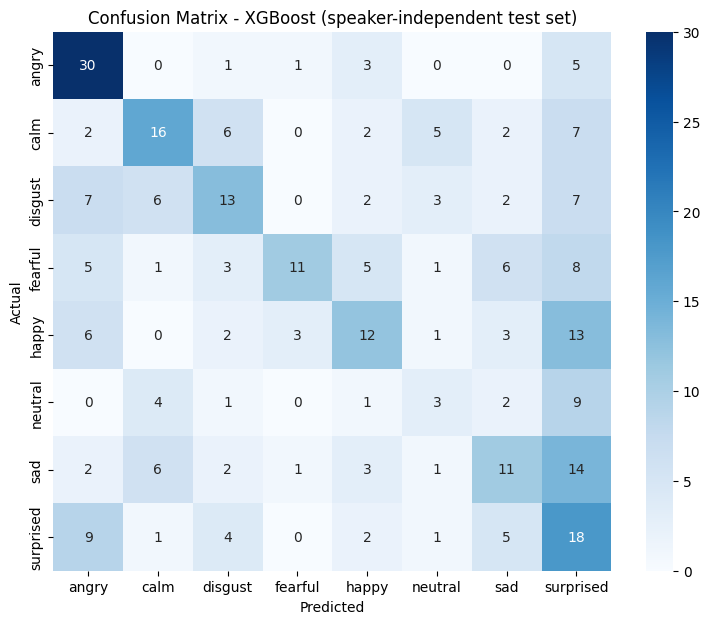

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_enc, xgb_preds)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - XGBoost (speaker-independent test set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test_enc, xgb_preds)
results_table = pd.DataFrame({
    'Emotion': le.classes_,
    'Precision': precision.round(2),
    'Recall': recall.round(2),
    'F1-score': f1.round(2),
    'Support': support
})
print(results_table)

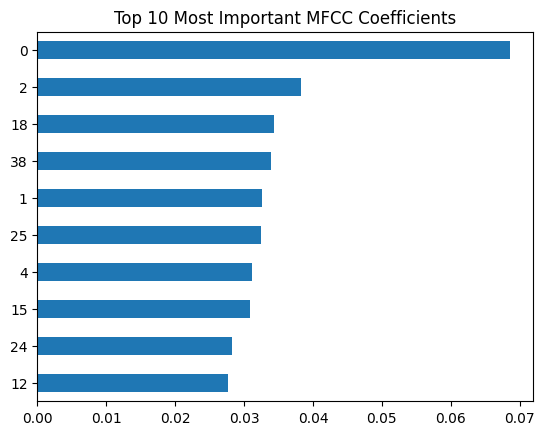

In [ ]:
importances = pd.Series(xgb_model.feature_importances_)
importances.sort_values(ascending=False)[:10].plot(kind='barh')
plt.title('Top 10 Most Important MFCC Coefficients')
plt.gca().invert_yaxis()
plt.show()